In [2]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_diabetes

In [6]:
df=pd.read_csv("diabetes.csv")

In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
x=df.iloc[:,0:8]

In [14]:
y=df["Outcome"]

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)

In [22]:
lg=LogisticRegression(max_iter=1000)
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
y_pred=lg.predict_proba(x_test)[:,1]
y_pred

array([0.95987904, 0.16519081, 0.09467772, 0.63345991, 0.12292173,
       0.03809727, 0.74122939, 0.84726316, 0.37567033, 0.36744866,
       0.56993129, 0.95938401, 0.28561764, 0.16999486, 0.12298051,
       0.16033126, 0.86299154, 0.02700743, 0.42823796, 0.25392378,
       0.66531669, 0.42139942, 0.22250972, 0.06509016, 0.05057897,
       0.36536776, 0.04558831, 0.9071553 , 0.11377645, 0.14423564,
       0.45982287, 0.25351734, 0.09406814, 0.45763202, 0.10221526,
       0.71908177, 0.45565532, 0.08603648, 0.34158474, 0.74791298,
       0.28323678, 0.21870824, 0.16030409, 0.83282843, 0.74368951,
       0.00869505, 0.08684103, 0.20510297, 0.3548717 , 0.30220345,
       0.40678397, 0.19190159, 0.87380947, 0.49771157, 0.13822043,
       0.00272802, 0.06243716, 0.5586952 , 0.27872215, 0.07331703,
       0.72497835, 0.4659272 , 0.11001615, 0.72497127, 0.69279573,
       0.90504371, 0.7207066 , 0.1435357 , 0.36250036, 0.11070033,
       0.12646882, 0.41119611, 0.10134565, 0.95136119, 0.85303

In [31]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

In [32]:
thresholds

array([       inf, 0.95987904, 0.95938401, 0.9071553 , 0.74871633,
       0.74791298, 0.66223278, 0.63850272, 0.63345991, 0.6245354 ,
       0.5586952 , 0.54131399, 0.52689855, 0.45717009, 0.45565532,
       0.42372977, 0.42139942, 0.40678397, 0.39688036, 0.39377273,
       0.38991679, 0.36250036, 0.34871342, 0.3103867 , 0.30220345,
       0.29479685, 0.29013433, 0.28323678, 0.27872215, 0.25351734,
       0.24739194, 0.20656832, 0.20510297, 0.19190159, 0.1898562 ,
       0.07349081, 0.07331703, 0.00272802])

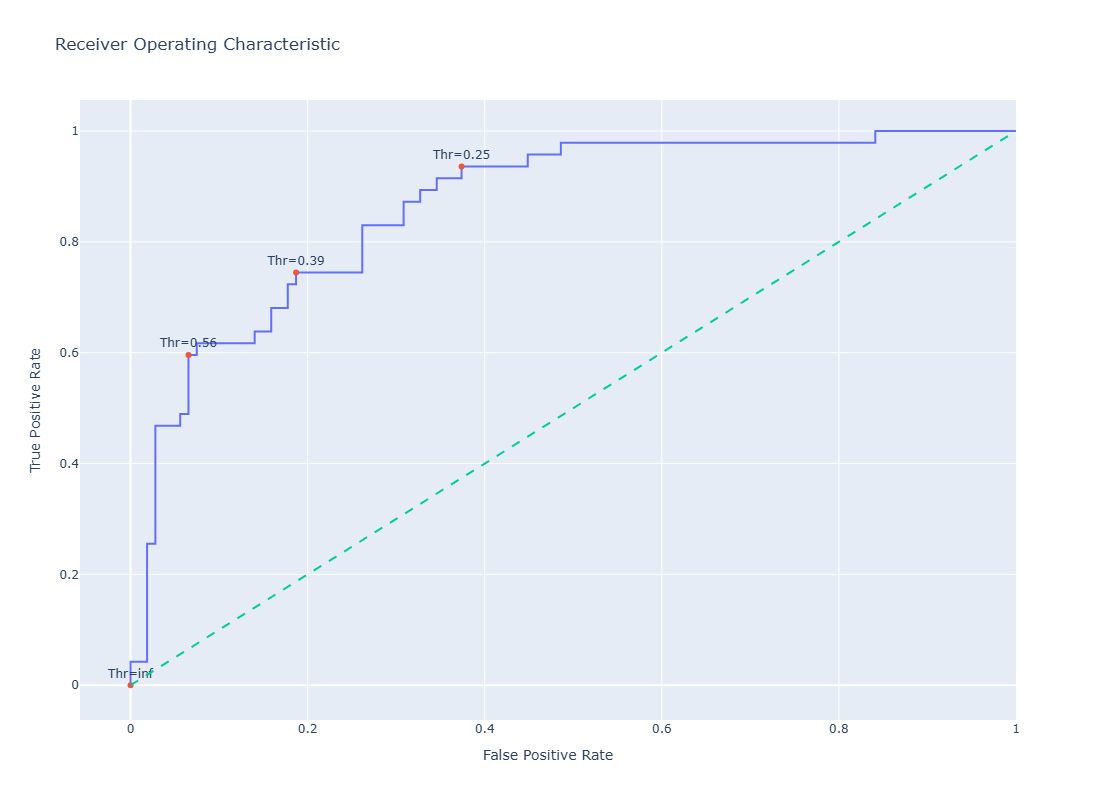

In [35]:
import plotly.graph_objects as go
import numpy as np


# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC curve'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [36]:
# Assume that fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)


Optimal threshold is: 0.2787221500791744


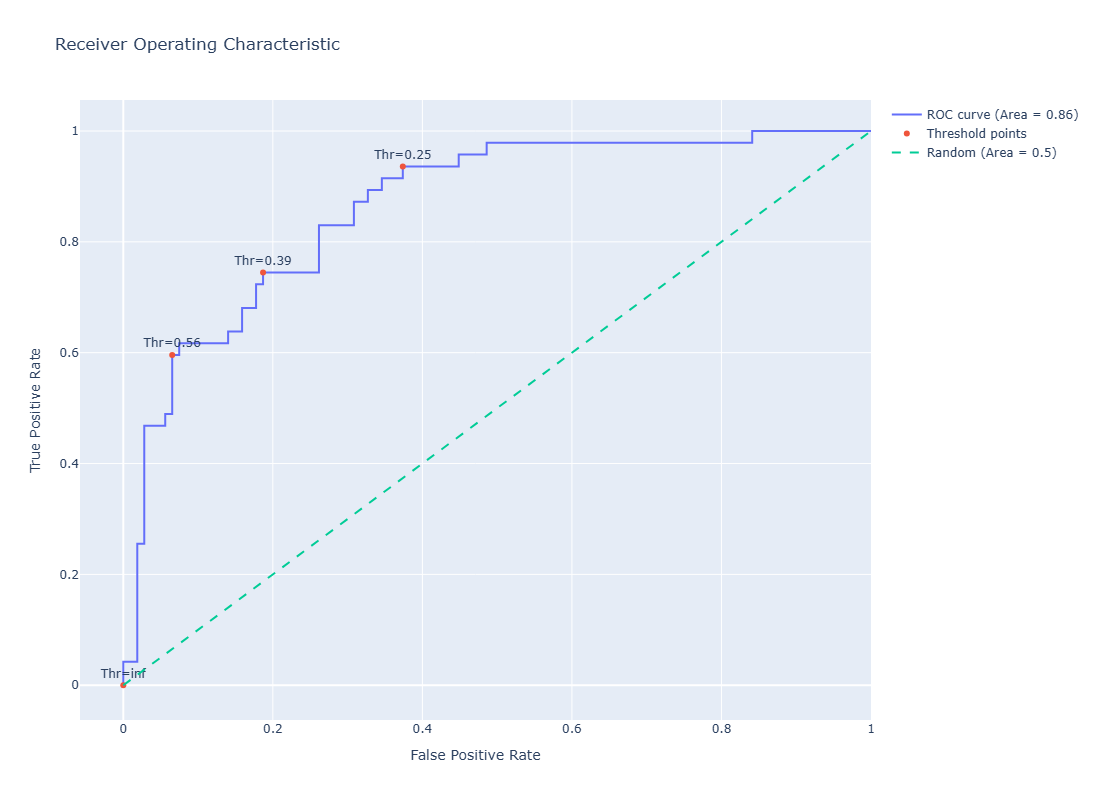

In [38]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import roc_auc_score

# Assuming fpr, tpr, thresholds are already calculated as before
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate the AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_pred)

# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC curve (Area = {roc_auc:.2f})'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()
